In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [282]:
embed_data = np.load('embed_data.npz', allow_pickle=True)

Intro = """
This is an exploration of how words (tokens) are represented inside an AI language model like ChatGPT. 
Words are first encoded as a sequence of tokens (numbers) using a process called tokenization. 
This, of course, is necessary as computers cannot really process words directly. 
The tokenization process is done by a tokenizer. 
Once this conversion process is done, these tokens are then embedded into a high-dimensional space using an embedding layer. 
And it is these high-dimensional embeddings that are passed forward through the model to predict the next word. 
A simple (very) way of describing what happens inside the model is that as the embeddings move through the model, 
each attention layer calculates an update to this embedding such that it is moved closer to the representation of 
the next word in the sentence, given the preceding context. 
I wondered whether it might be possible to observe these changes in the embeddings as they move through the model.
So thats what I am trying to do here.

I must say that this is not a tutorial or a guide. It is just me sharing some of my own explorations and learnings.
So if some of this is confusing, I apologize in advance. But all you need to know is that I am exploring how the inner representation
of words is updated as it moves through the model.
"""

text2 = """
These embeddings ofcourse can be high dimentional. For example largest GPT3 model has 12288 dimensions for each token embedding (as far as I am aware).
So I will be using a smaller model to keep the computations tractable.
"""




In [283]:
embed_data = np.load('embed_data.npz', allow_pickle=True)
embed_data.files

['full_embeddings',
 'compressed_embeddings',
 'embed_mean',
 'Vt',
 'U',
 'S',
 'full_hidden_sent0',
 'target_hidden_full_sent0',
 'target_hidden_compressed_sent0',
 'tokenized_sent0',
 'target_token0',
 'target_idx0',
 'full_hidden_sent1',
 'target_hidden_full_sent1',
 'target_hidden_compressed_sent1',
 'tokenized_sent1',
 'target_token1',
 'target_idx1',
 'full_hidden_sent2',
 'target_hidden_full_sent2',
 'target_hidden_compressed_sent2',
 'tokenized_sent2',
 'target_token2',
 'target_idx2']

In [ ]:
embed_data = np.load('embed_data.npz', allow_pickle=True)
full_dots = np.load('embedding_dot_products.npz')

Sentence1 = 'This is the very first example sentense.'
target1 = ' first'
Sentence2 = 'Is it true that pain and pleasure are two sides of the same coin?'
target2 = ' pain'
Sentence3 = 'Our brains turn fleeting sensations into the stories we live by.'
target3 = ' fleeting'
sentences = [Sentence1, Sentence2, Sentence3]
targets = [target1, target2, target3]

sent = 2
full_sentence_hidden = embed_data[f'full_hidden_sent{sent}']
target_hidden = embed_data[f'target_hidden_compressed_sent{sent}']
full_hidden_full = embed_data[f'full_hidden_sent{sent}']
target_hidden_full = embed_data[f'target_hidden_full_sent{sent}']
hidden_norms = np.linalg.norm(embed_data[f'target_hidden_compressed_sent{sent}'], axis=1, keepdims=True)
target_hidden_compressed = embed_data[f'target_hidden_compressed_sent{sent}'] / hidden_norms
tokenized_sent = embed_data[f'tokenized_sent{sent}']
full_sentence_embeds = embed_data['full_embeddings'][tokenized_sent,:]
full_sentence_embed_norms = np.linalg.norm(full_sentence_embeds, axis=1, keepdims=True)
sentence_embeds = embed_data['compressed_embeddings'][tokenized_sent,:]
sentence_embeds = sentence_embeds / np.linalg.norm(sentence_embeds, axis=1, keepdims=True)
sent_text = sentences[sent]
target_idx = embed_data[f'target_idx{sent}']
words = sent_text.split(' ')
if sent == 1:
    words = words + ['?']
else:
    words =  words + ['.']

if sent == 0:
    sentence_embeds = np.delete(sentence_embeds, 6, axis=0)
print(words)
assert len(words) == sentence_embeds.shape[0], print(len(words), sentence_embeds.shape[0])


# Compute cosine Similarities 
from sklearn.metrics.pairwise import cosine_similarity

next_word_embed = full_sentence_embeds[target_idx+1,:]
this_word_embed = full_sentence_embeds[target_idx,:]

target_hidden_full[0,:] = this_word_embed

dots = [
    np.dot(target_hidden_full[i, :], next_word_embed)
    for i in range(target_hidden_full.shape[0])
]

cos_sims = [
    cosine_similarity([target_hidden_full[i, :]], [next_word_embed])[0,0]
    for i in range(target_hidden_full.shape[0])
]


['Our', 'brains', 'turn', 'fleeting', 'sensations', 'into', 'the', 'stories', 'we', 'live', 'by.', '.']


In [ ]:


# draw a subsample of the dot products

array([102.956314,  69.39311 ,  64.654465], dtype=float32)

/var/folders/f0/yk_38ks9693585hklt0mrt9h0000gp/T/ipykernel_21951/967245073.py:71: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot_line.set_data(range(len(dot_data)), dot_data[0]+2)


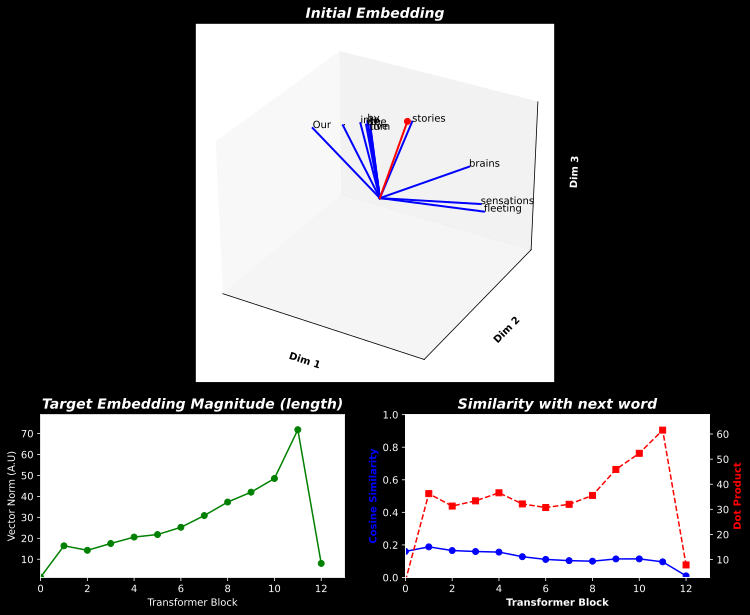

In [298]:
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec


target_hidden_compressed = target_hidden_compressed[:,[1,2,0]]
sentence_embeds = sentence_embeds[:,[1,2,0]]


# Setup figure with 2x2 grid
fig = plt.figure(figsize=(12, 10), facecolor='black')  

# --- 3D Plot ---
# ax3d = fig.add_subplot(2, 2, 1, projection='3d')
gs = GridSpec(3, 2, figure=fig)
ax3d = fig.add_subplot(gs[0:2, :], projection='3d')


for i, vec in enumerate(sentence_embeds):
    ax3d.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color='blue', linewidth=2)
    ax3d.text(vec[0], vec[1], vec[2], words[i], size=10, color='black')

ax3d.set_xlim([-1 ,1])
ax3d.set_ylim([-1, 1])
ax3d.set_zlim([-1, 1])
ax3d.set_title("Embedding Trajectory", color='white', fontsize=14, fontweight='bold', fontstyle='italic')
ax3d.set_xlabel('Dim 1', color='black', fontweight='bold')
ax3d.set_ylabel('Dim 2', color='black', fontweight='bold')
ax3d.set_zlabel('Dim 3', color='white', fontweight='bold')
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])

ax3d.set_xticklabels([])
ax3d.set_yticklabels([])
ax3d.set_zticklabels([])

target_vec = sentence_embeds[target_idx]
animated_line, = ax3d.plot([0, target_vec[0]], [0, target_vec[1]], [0, target_vec[2]], color='red', linewidth=2)
trail, = ax3d.plot([], [], [], 'ro-', linewidth=1)

# --- Norms Plot ---
# ax_norms = fig.add_subplot(2, 2, 3)
ax_norms = fig.add_subplot(gs[2, 0])
ax_norms.set_xlabel('Transformer Block', color="white")
ax_norms.set_ylabel('Vector Norm (A.U)', color="white")
ax_norms.set_title('Target Embedding Magnitude (length)', fontsize=14, fontweight='bold', fontstyle='italic', color="white")
norm_line, = ax_norms.plot([], [], 'go-')
norm_data = []

# --- Cosine + Dot Similarity Plot ---
# ax_cos = fig.add_subplot(2, 2, 4)
ax_cos = fig.add_subplot(gs[2, 1])
ax_dot = ax_cos.twinx()
ax_cos.set_ylabel('Cosine Similarity', color='blue', fontweight='bold')
ax_cos.set_title('Similarity with next word', fontsize=14, fontweight='bold', fontstyle='italic', color="white")
ax_dot.set_ylabel('Dot Product', color='red', fontweight='bold')
ax_cos.set_xlabel('Transformer Block', color='white', fontweight="bold")
cos_line, = ax_cos.plot([], [], 'bo-', label='Cosine Similarity')
dot_line, = ax_dot.plot([], [], 'rs--', label='Dot Product')
cos_data = []
dot_data = []


# Initialize the plots with the first values
norm_data = [hidden_norms[0][0]]
cos_data = [cos_sims[0]]
dot_data = [dots[0]]

norm_line.set_data(range(len(norm_data)), norm_data)
cos_line.set_data(range(len(cos_data)), cos_data)
dot_line.set_data(range(len(dot_data)), dot_data[0]+2)

# Update limits so initial values are visible
ax_norms.set_xlim(0, len(hidden_norms))
ax_norms.set_ylim(min(norm_data) * 0.9, max(hidden_norms)[0] * 1.1)

ax_cos.set_xlim(0, len(cos_sims))
ax_cos.set_ylim(0, 1)  # Cosine similarity range
ax_dot.set_ylim(min(dots[1:]) - 5, max(dots[1:]) * 1.1)

# Apply to norm and cosine/dot plots
for ax in [ax_norms, ax_cos, ax_dot]:
    ax.tick_params(colors='white')  # Make tick labels white
    for spine in ax.spines.values():  # Make border lines white
        spine.set_color('white')

# --- Update function ---
def update(frame):

    if frame == 0:
        vec = target_hidden_compressed[frame]

        # Update 3D line and trail
        animated_line.set_data([0, vec[0]], [0, vec[1]])
        animated_line.set_3d_properties([0, vec[2]])
        trail.set_data(target_hidden_compressed[:frame+1, 0], target_hidden_compressed[:frame+1, 1])
        trail.set_3d_properties(target_hidden_compressed[:frame+1, 2])
        ax3d.set_title(f"Transformer Block: {frame}" if frame > 0 else "Initial Embedding", fontsize=14, fontweight='bold', fontstyle='italic')
        return animated_line, trail, cos_line, dot_line, norm_line
        
    vec = target_hidden_compressed[frame]
    
    # Update 3D line and trail
    animated_line.set_data([0, vec[0]], [0, vec[1]])
    animated_line.set_3d_properties([0, vec[2]])
    trail.set_data(target_hidden_compressed[:frame+1, 0], target_hidden_compressed[:frame+1, 1])
    trail.set_3d_properties(target_hidden_compressed[:frame+1, 2])
    ax3d.set_title(f"Transformer Block: {frame}" if frame > 0 else "Initial Embedding", fontsize=14, fontweight='bold', fontstyle='italic')

    # Update norm plot
    norm_data.append(hidden_norms[frame][0])
    norm_line.set_data(range(len(norm_data)), norm_data)

    # Update cosine + dot similarity
    cos_data.append(cos_sims[frame])
    dot_data.append(dots[frame])
    cos_line.set_data(range(len(cos_data)), cos_data)
    dot_line.set_data(range(len(dot_data)), dot_data)


    return animated_line, trail, cos_line, dot_line, norm_line

# Run the animation
ani = FuncAnimation(fig, update, frames=len(target_hidden_compressed), interval=600, blit=False)
ani.save(f"embedding_with_similarity_and_norms{sent}.gif", writer="pillow", fps=1)

98.16014